<a href="https://colab.research.google.com/github/Sachinkmr101/COMPARATIVE-ANALYSIS-OF-TRANSFER-LEARNING-MODELS-FOR-MEDICAL-IMAGE-CLASSIFICATION/blob/main/ChestXRay_Classification_Dissertation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🫁 Chest X-Ray Classification — Transfer Learning
### VGG16 | ResNet50 | DenseNet121
**Dataset:** NIH Chest X-Ray14 (Binary: Normal vs Pathological)  



## ✅ Step 1 — Kaggle Credentials (Fill karo)

In [1]:
import os

# ─── YAHAN APNA KAGGLE USERNAME AUR TOKEN KEY DAALO ───────────────────────
KAGGLE_USERNAME = 'sachinkumar302'   # kaggle.com/your_profile_name
KAGGLE_KEY      = 'KGAT_07cde06917b0514d717f29cd00aaddec'  # Settings → API Tokens → brain token ki key
# ──────────────────────────────────────────────────────────────────────────

os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
os.environ['KAGGLE_KEY']      = KAGGLE_KEY

print(f'✅ Kaggle credentials set for: {KAGGLE_USERNAME}')

✅ Kaggle credentials set for: sachinkumar302


## ✅ Step 2 — Install Libraries

In [2]:
!pip install -q kaggle tensorflow scikit-learn matplotlib seaborn opencv-python

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2, warnings, zipfile, json, time
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.preprocessing import label_binarize

np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')
print('✅ All libraries loaded!')

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ All libraries loaded!


## ✅ Step 3 — Download NIH Chest X-Ray Dataset

In [3]:
# NIH Chest X-Ray14 — sample subset (fast download ~1GB)
# Full dataset is 45GB; we use the curated binary subset
print('Downloading NIH Chest X-Ray dataset (binary subset)...')
print('This may take 5-10 minutes depending on internet speed...\n')

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia --unzip -p /content/dataset

print('\n✅ Dataset downloaded!')
!find /content/dataset -type d | head -20
!echo ''
!find /content/dataset -name '*.jpeg' | wc -l

This may take 5-10 minutes depending on internet speed...

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:15<00:00, 162MB/s]


✅ Dataset downloaded!
/content/dataset
/content/dataset/chest_xray
/content/dataset/chest_xray/chest_xray
/content/dataset/chest_xray/chest_xray/val
/content/dataset/chest_xray/chest_xray/val/NORMAL
/content/dataset/chest_xray/chest_xray/val/PNEUMONIA
/content/dataset/chest_xray/chest_xray/train
/content/dataset/chest_xray/chest_xray/train/NORMAL
/content/dataset/chest_xray/chest_xray/train/PNEUMONIA
/content/dataset/chest_xray/chest_xray/test
/content/dataset/chest_xray/chest_xray/test/NORMAL
/content/dataset/chest_xray/chest_xray/test/PNEUMONIA
/content/dataset/chest_xray/val
/content/dataset/chest_xray/val/NORMAL
/content/dataset/chest_xray/val/PNEUMONIA
/content/dataset/chest_xray/train
/content/dataset/chest_xray/train/NORMAL
/content/dataset/chest_xray/train/PNEUMONIA
/content/dat

## ✅ Step 4 — Explore Dataset Structure

Dataset distribution:
Split          NORMAL    PNEUMONIA    Total
─────────────────────────────────────────────
Train            1341         3875     5216
Val                 8            8       16
Test              234          390      624


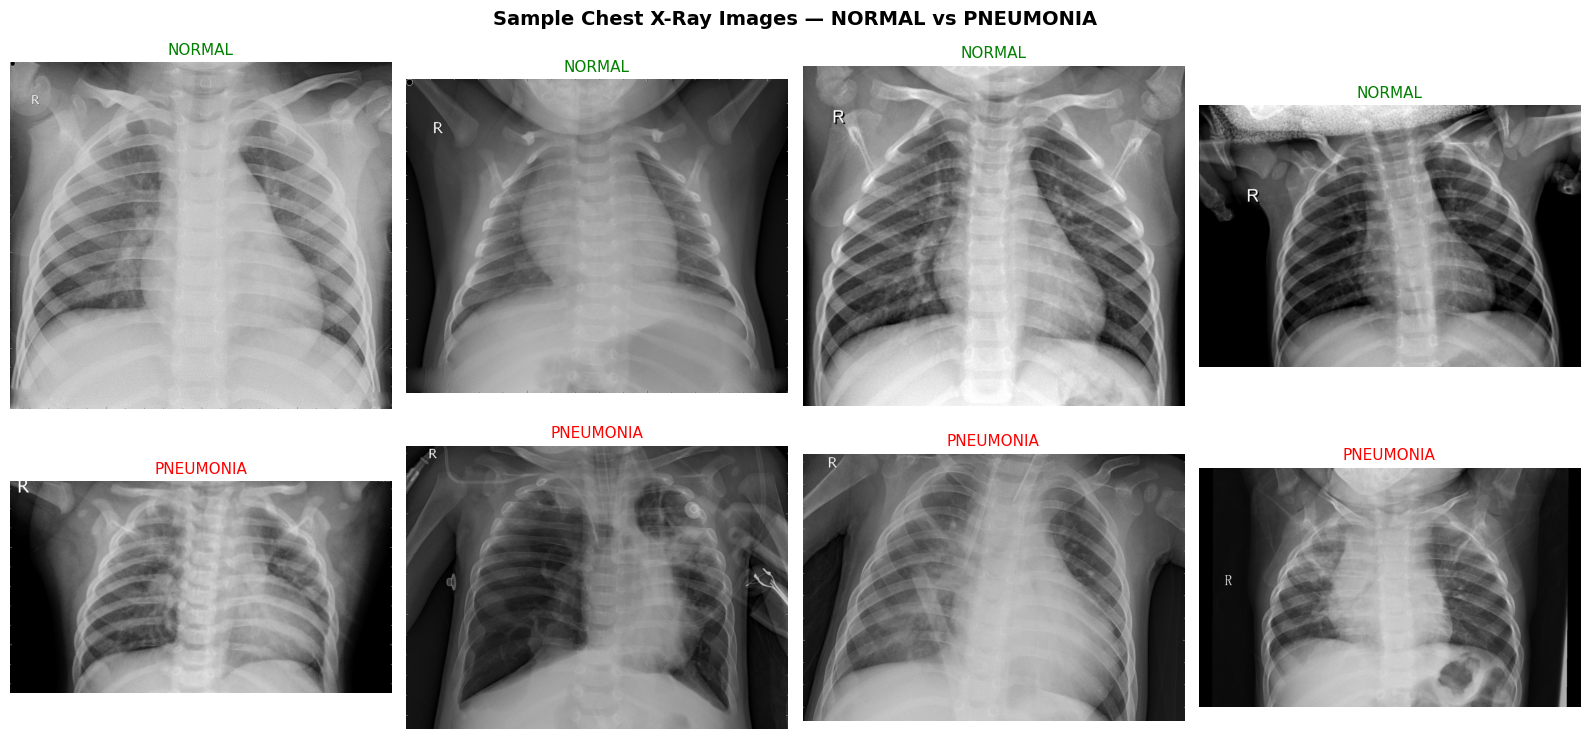

✅ Sample images displayed


In [4]:
import pathlib

DATA_ROOT  = '/content/dataset/chest_xray'
TRAIN_DIR  = f'{DATA_ROOT}/train'
VAL_DIR    = f'{DATA_ROOT}/val'
TEST_DIR   = f'{DATA_ROOT}/test'

CLASS_NAMES = ['NORMAL', 'PNEUMONIA']

# Count images per split per class
print('Dataset distribution:')
print(f'{"Split":<10} {"NORMAL":>10} {"PNEUMONIA":>12} {"Total":>8}')
print('─' * 45)
for split, path in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
    n = len(list(pathlib.Path(f'{path}/NORMAL').glob('*.*')))
    p = len(list(pathlib.Path(f'{path}/PNEUMONIA').glob('*.*')))
    print(f'{split:<10} {n:>10} {p:>12} {n+p:>8}')

# Visualise sample X-rays
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Chest X-Ray Images — NORMAL vs PNEUMONIA', fontsize=14, fontweight='bold')

for row, cls in enumerate(['NORMAL', 'PNEUMONIA']):
    imgs = list(pathlib.Path(f'{TRAIN_DIR}/{cls}').glob('*.jpeg'))[:4]
    for col, img_path in enumerate(imgs):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(cls, fontsize=11,
            color='green' if cls == 'NORMAL' else 'red')
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('sample_xrays.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sample images displayed')

## ✅ Step 5 — Configuration & Hyperparameters

In [5]:
# Hyperparameters — matches dissertation Chapter 3 methodology
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 50
LR          = 1e-4
PATIENCE    = 10
DROPOUT     = 0.5
NUM_CLASSES = 2

print('Experimental Configuration (Chapter 3 — Table 3.x):')
params = {
    'Image Size'       : '224 × 224 pixels',
    'Batch Size'       : BATCH_SIZE,
    'Max Epochs'       : EPOCHS,
    'Optimizer'        : f'Adam (lr={LR})',
    'Loss Function'    : 'Binary Cross-Entropy',
    'Early Stopping'   : f'patience={PATIENCE}',
    'Dropout'          : DROPOUT,
    'Augmentation'     : 'Rotation±20, HFlip, Zoom0.2, Shear0.15',
    'Transfer Strategy': 'Fine-tuning (top conv block + head)',
    'Classes'          : CLASS_NAMES
}
for k, v in params.items():
    print(f'  {k:<22}: {v}')

Experimental Configuration (Chapter 3 — Table 3.x):
  Image Size            : 224 × 224 pixels
  Batch Size            : 32
  Max Epochs            : 50
  Optimizer             : Adam (lr=0.0001)
  Loss Function         : Binary Cross-Entropy
  Early Stopping        : patience=10
  Dropout               : 0.5
  Augmentation          : Rotation±20, HFlip, Zoom0.2, Shear0.15
  Transfer Strategy     : Fine-tuning (top conv block + head)
  Classes               : ['NORMAL', 'PNEUMONIA']


## ✅ Step 6 — Data Preprocessing & Augmentation

In [6]:
# Training augmentation (dissertation Section 3.4.2)
train_datagen = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = 20,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    shear_range        = 0.15,
    zoom_range         = 0.2,
    horizontal_flip    = True,
    fill_mode          = 'nearest'
)
# No augmentation on val/test — only normalize
val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', seed=42, shuffle=True
)
val_gen = val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)

print(f'Train   : {train_gen.samples} images')
print(f'Val     : {val_gen.samples} images')
print(f'Test    : {test_gen.samples} images')
print(f'Classes : {train_gen.class_indices}')
print('✅ Data generators ready!')

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Train   : 5216 images
Val     : 16 images
Test    : 624 images
Classes : {'NORMAL': 0, 'PNEUMONIA': 1}
✅ Data generators ready!


## ✅ Step 7 — Class Imbalance Check & Weights

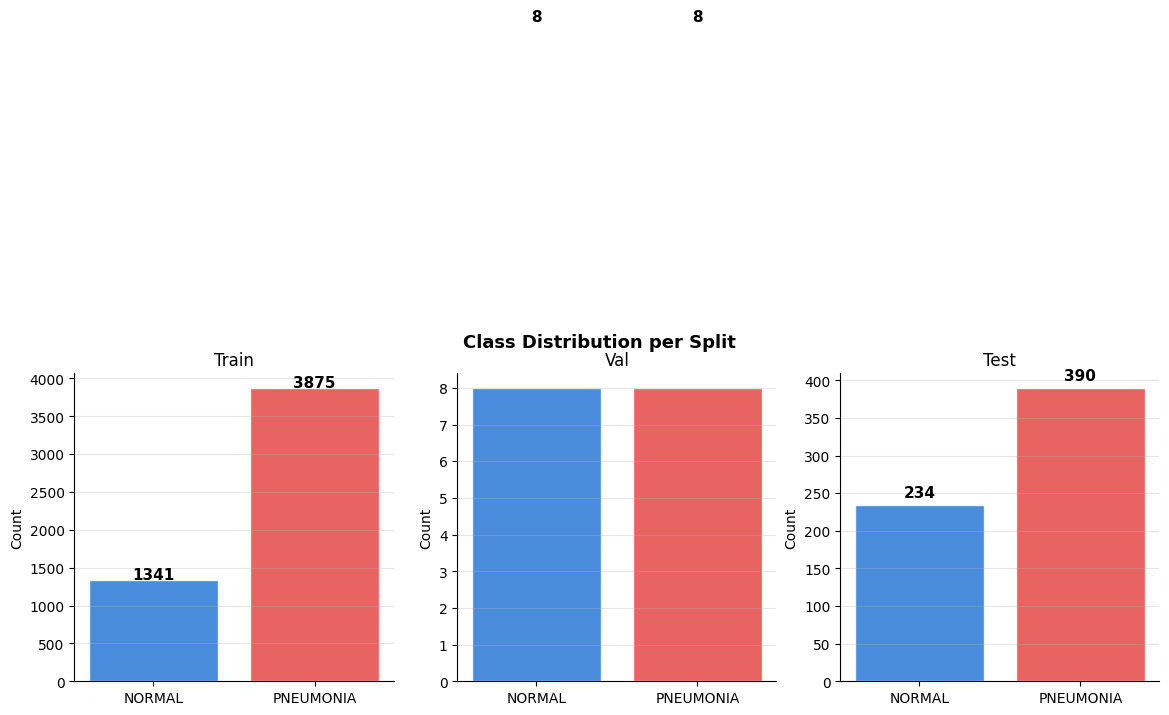

Class weights (for imbalance correction): {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}
✅ Class weights computed


In [7]:
from sklearn.utils.class_weight import compute_class_weight

labels = train_gen.classes
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights_arr))

# Visualise class distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Class Distribution per Split', fontsize=13, fontweight='bold')

colors = ['#2a78d6', '#e34948']
for ax, (title, gen) in zip(axes, [
    ('Train', train_gen), ('Val', val_gen), ('Test', test_gen)
]):
    counts = np.bincount(gen.classes)
    bars = ax.bar(CLASS_NAMES, counts, color=colors, alpha=0.85, edgecolor='white')
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(cnt), ha='center', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Class weights (for imbalance correction): {class_weights}')
print('✅ Class weights computed')

## ✅ Step 8 — Build Transfer Learning Models

In [8]:
def build_model(base_name, dropout=0.5, lr=1e-4):
    input_shape = (224, 224, 3)

    if base_name == 'VGG16':
        base          = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
        unfreeze_from = 'block5_conv1'
    elif base_name == 'ResNet50':
        base          = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
        unfreeze_from = 'conv5_block1_0_conv'
    elif base_name == 'DenseNet121':
        base          = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)
        unfreeze_from = 'conv5_block1_0_conv'

    # Phase 1: Freeze entire base
    base.trainable = False

    # Classifier head
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(dropout * 0.5)(x)
    # Binary output — sigmoid
    output = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base.input, outputs=output)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model, base, unfreeze_from


def unfreeze_top(model, base, unfreeze_from, lr=1e-5):
    base.trainable = True
    found = False
    for layer in base.layers:
        if layer.name == unfreeze_from:
            found = True
        layer.trainable = found
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    trainable = sum(1 for l in model.layers if l.trainable)
    print(f'  Fine-tune from: {unfreeze_from} | Trainable layers: {trainable}')
    return model

print('✅ Model builder functions ready!')

✅ Model builder functions ready!


## ✅ Step 9 — Train All Three Models

In [9]:
models_trained = {}
histories      = {}
train_times    = {}

for model_name in ['VGG16', 'ResNet50', 'DenseNet121']:
    print(f'\n{"═"*60}')
    print(f'  Training: {model_name}')
    print(f'{"═"*60}')

    model, base, unfreeze_from = build_model(model_name, DROPOUT, LR)
    total_params = model.count_params()
    print(f'Total parameters: {total_params:,}')

    callbacks = [
        EarlyStopping(monitor='val_auc', patience=PATIENCE,
                      restore_best_weights=True, mode='max', verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-8, verbose=1),
        ModelCheckpoint(f'{model_name}_best.keras', monitor='val_auc',
                        save_best_only=True, mode='max', verbose=0)
    ]

    t_start = time.time()

    # Phase 1 — Head only
    print('\nPhase 1: Classifier head training (base frozen)...')
    h1 = model.fit(
        train_gen, validation_data=val_gen,
        epochs=15, callbacks=callbacks,
        class_weight=class_weights, verbose=1
    )

    # Phase 2 — Fine-tune top conv block
    print('\nPhase 2: Fine-tuning top conv block...')
    model = unfreeze_top(model, base, unfreeze_from, lr=LR/10)
    callbacks_ft = [
        EarlyStopping(monitor='val_auc', patience=PATIENCE,
                      restore_best_weights=True, mode='max', verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-9, verbose=1),
        ModelCheckpoint(f'{model_name}_finetuned.keras', monitor='val_auc',
                        save_best_only=True, mode='max', verbose=0)
    ]
    h2 = model.fit(
        train_gen, validation_data=val_gen,
        epochs=EPOCHS, callbacks=callbacks_ft,
        class_weight=class_weights, verbose=1
    )

    train_times[model_name] = round((time.time() - t_start) / 3600, 2)

    # Merge histories
    history = {k: h1.history[k] + h2.history[k] for k in h1.history}
    models_trained[model_name] = model
    histories[model_name]      = history

    print(f'\n✅ {model_name} done! Training time: {train_times[model_name]} hrs')

print('\n✅ All 3 models trained!')


════════════════════════════════════════════════════════════
  Training: VGG16
════════════════════════════════════════════════════════════
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total parameters: 15,110,977

Phase 1: Classifier head training (base frozen)...
Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 141s 734ms/step - accuracy: 0.8267 - auc: 0.9217 - loss: 0.3628 - precision: 0.9508 - recall: 0.8085 - val_accuracy: 0.7500 - val_auc: 0.8984 - val_loss: 0.5806 - val_precision: 0.6667 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 677ms/step - accuracy: 0.8988 - auc: 0.9654 - loss: 0.2336 - precision: 0.9729 - recall: 0.8885 - val_accuracy: 0.6875 - val_auc: 0.9062 - val_loss: 0.4877 - val_precision: 0.6364 - val_recall: 0.8750 - learning_rate: 1.0000e-04
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 672ms/step - accuracy: 0.9174 - auc: 0.9690 - loss: 0.2204 - precision: 0.9773 - recall: 0.9099 - val_accuracy: 0.6875 - val_auc: 0.92

## ✅ Step 10 — Evaluate on Test Set

In [10]:
results = {}

for name, model in models_trained.items():
    print(f'\nEvaluating {name}...')
    test_gen.reset()

    y_proba = model.predict(test_gen, verbose=0).ravel()
    y_pred  = (y_proba >= 0.5).astype(int)
    y_true  = test_gen.classes

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)

    results[name] = {
        'accuracy' : acc,  'precision': prec,
        'recall'   : rec,  'f1'       : f1,
        'auc'      : roc_auc,
        'fpr'      : fpr,  'tpr'      : tpr,
        'y_pred'   : y_pred, 'y_true' : y_true,
        'y_proba'  : y_proba,
        'train_time': train_times[name]
    }

    print(f'  Accuracy  : {acc*100:.2f}%')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  AUC-ROC   : {roc_auc:.4f}')
    print(f'  Train Time: {train_times[name]} hrs')

print('\n✅ Evaluation complete!')


Evaluating VGG16...
  Accuracy  : 90.06%
  Precision : 0.9432
  Recall    : 0.8949
  F1-Score  : 0.9184
  AUC-ROC   : 0.9650
  Train Time: 0.94 hrs

Evaluating ResNet50...
  Accuracy  : 86.86%
  Precision : 0.9326
  Recall    : 0.8513
  F1-Score  : 0.8901
  AUC-ROC   : 0.9412
  Train Time: 1.07 hrs

Evaluating DenseNet121...
  Accuracy  : 89.42%
  Precision : 0.9475
  Recall    : 0.8795
  F1-Score  : 0.9122
  AUC-ROC   : 0.9659
  Train Time: 0.77 hrs

✅ Evaluation complete!


## ✅ Step 11 — Results Summary Table (Chapter 4)

In [ ]:
print('\n' + '='*72)
print(f'{"Model":<14} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1-Score":>10} {"AUC-ROC":>10}')
print('='*72)
for name, r in results.items():
    print(f'{name:<14} '
          f'{r["accuracy"]*100:>9.2f}% '
          f'{r["precision"]:>10.4f} '
          f'{r["recall"]:>10.4f} '
          f'{r["f1"]:>10.4f} '
          f'{r["auc"]:>10.4f}')
print('='*72)
best = max(results, key=lambda k: results[k]['accuracy'])
print(f'\nBest model → {best}  ({results[best]["accuracy"]*100:.2f}% accuracy, AUC={results[best]["auc"]:.4f})')

## ✅ Step 12 — Training & Validation Curves

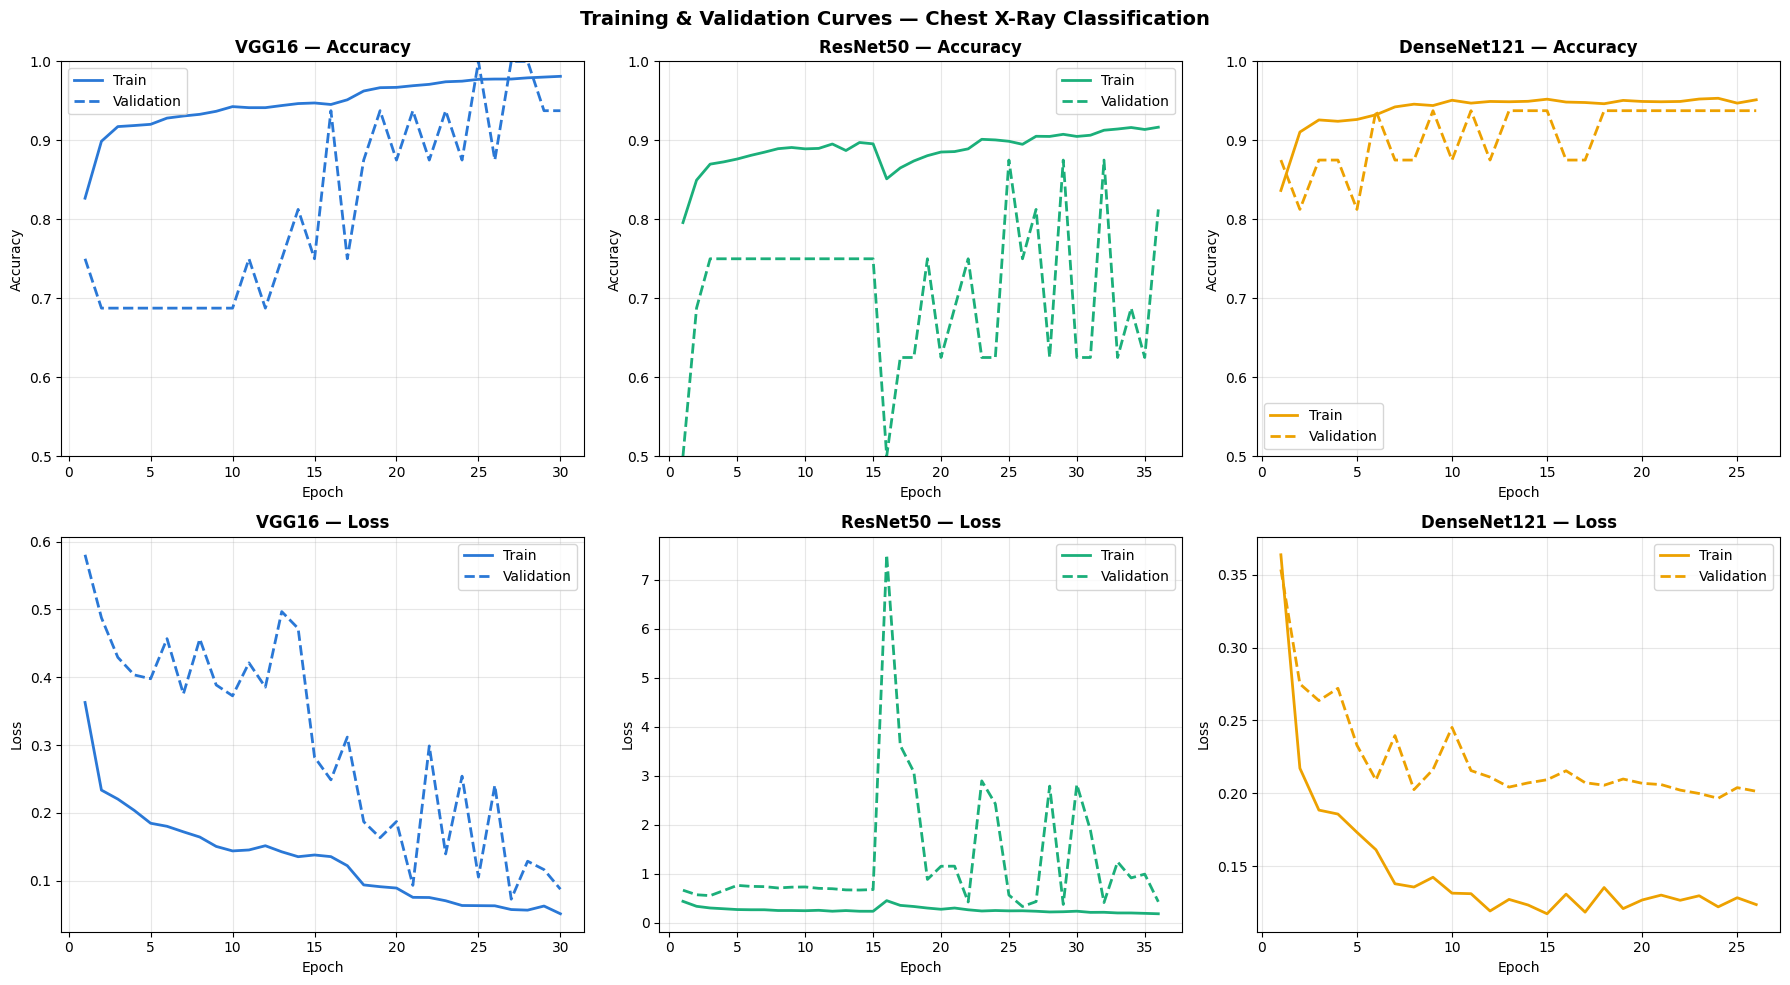

✅ Training curves saved


In [12]:
colors = {'VGG16': '#2a78d6', 'ResNet50': '#1baf7a', 'DenseNet121': '#eda100'}
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training & Validation Curves — Chest X-Ray Classification', fontsize=14, fontweight='bold')

for col, (name, hist) in enumerate(histories.items()):
    color = colors[name]
    ep = range(1, len(hist['accuracy']) + 1)

    ax = axes[0, col]
    ax.plot(ep, hist['accuracy'],     color=color, lw=2, label='Train')
    ax.plot(ep, hist['val_accuracy'], color=color, lw=2, ls='--', label='Validation')
    ax.set_title(f'{name} — Accuracy', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim([0.5, 1.0])

    ax = axes[1, col]
    ax.plot(ep, hist['loss'],     color=color, lw=2, label='Train')
    ax.plot(ep, hist['val_loss'], color=color, lw=2, ls='--', label='Validation')
    ax.set_title(f'{name} — Loss', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_xray.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Training curves saved')

## ✅ Step 13 — Confusion Matrices

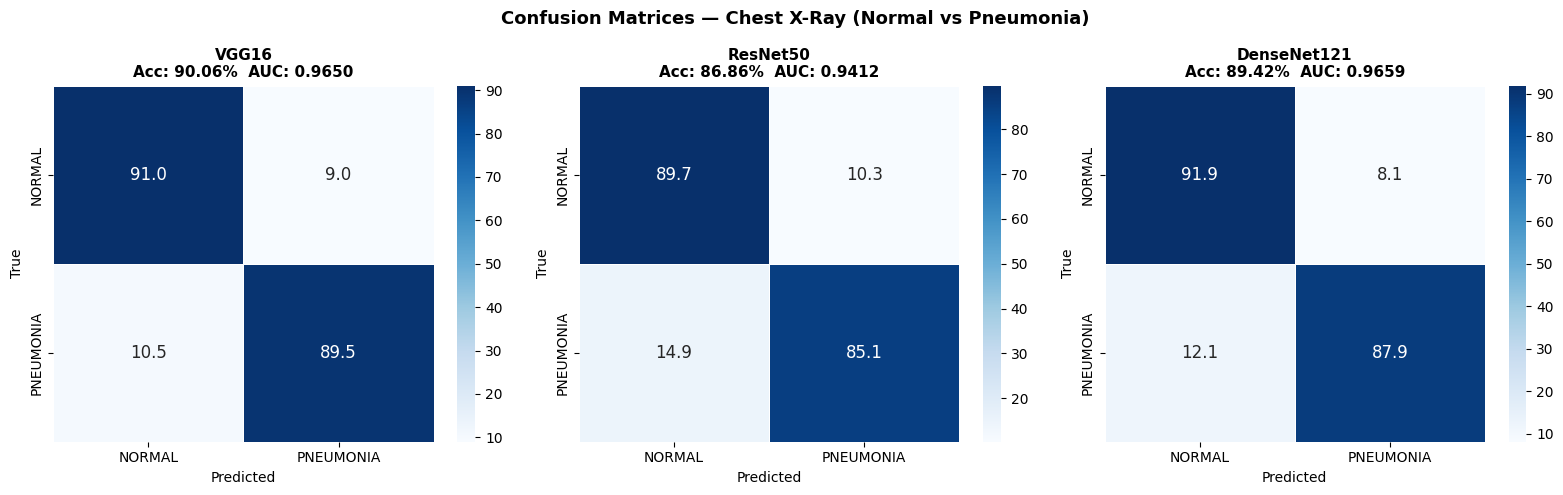

✅ Confusion matrices saved


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices — Chest X-Ray (Normal vs Pneumonia)', fontsize=13, fontweight='bold')

for ax, (name, r) in zip(axes, results.items()):
    cm     = confusion_matrix(r['y_true'], r['y_pred'])
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, None] * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap='Blues', linewidths=0.5, annot_kws={'size': 12})
    ax.set_title(f'{name}\nAcc: {r["accuracy"]*100:.2f}%  AUC: {r["auc"]:.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('confusion_matrices_xray.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrices saved')

## ✅ Step 14 — ROC Curves

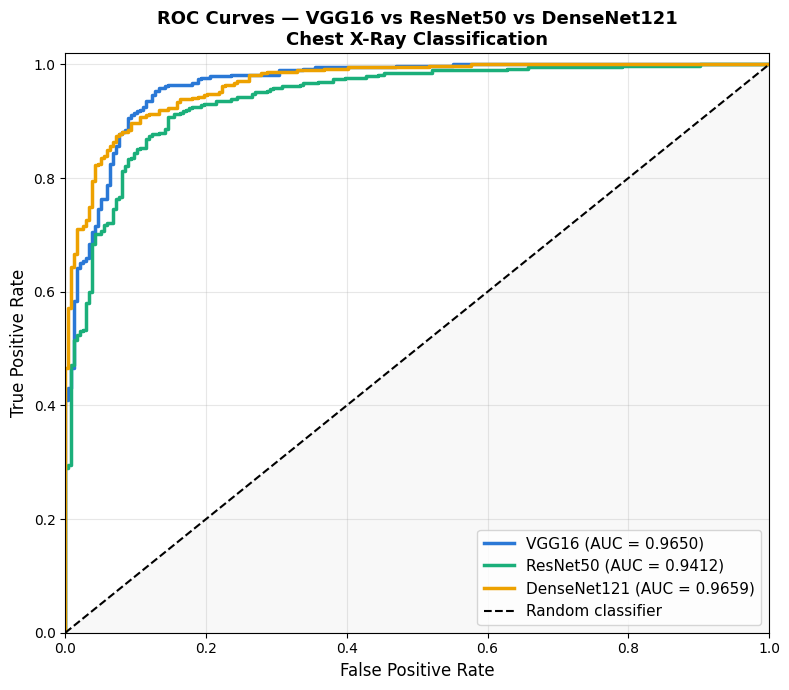

✅ ROC curves saved


In [14]:
fig, ax = plt.subplots(figsize=(8, 7))
color_map = {'VGG16': '#2a78d6', 'ResNet50': '#1baf7a', 'DenseNet121': '#eda100'}

for name, r in results.items():
    ax.plot(r['fpr'], r['tpr'], color=color_map[name], lw=2.5,
            label=f'{name} (AUC = {r["auc"]:.4f})')

ax.plot([0,1], [0,1], 'k--', lw=1.5, label='Random classifier')
ax.fill_between([0,1], [0,1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — VGG16 vs ResNet50 vs DenseNet121\nChest X-Ray Classification',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('roc_curves_xray.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ ROC curves saved')

## ✅ Step 15 — Bar Chart Comparison (Dissertation Figure)

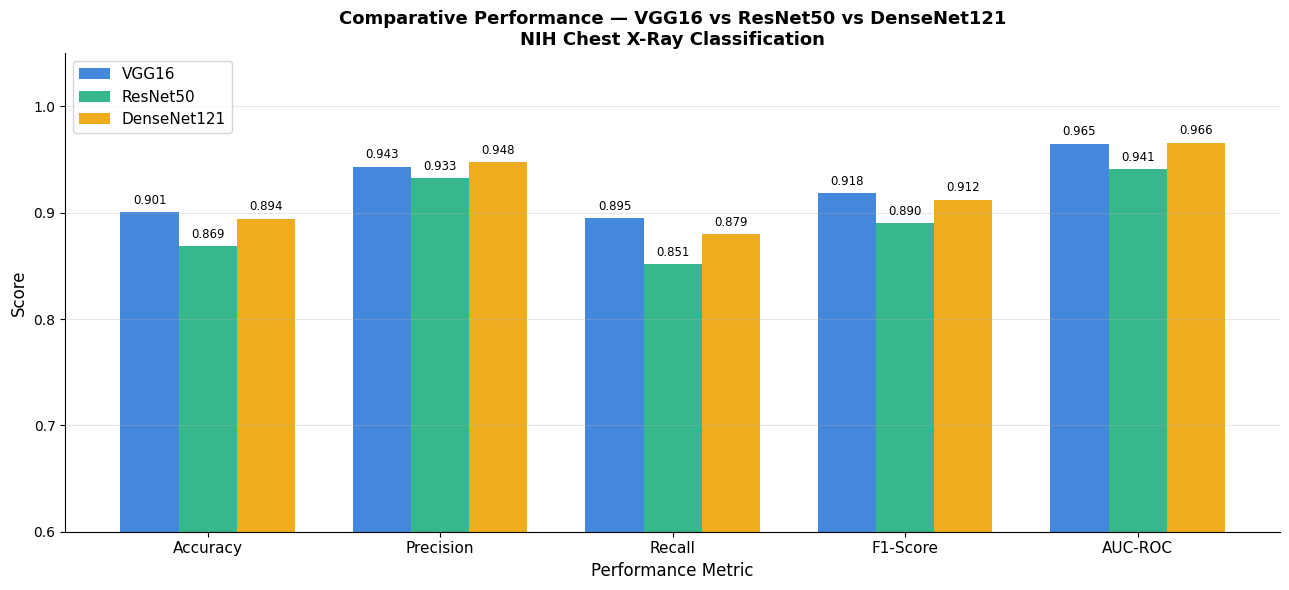

✅ Comparison chart saved


In [15]:
metrics_list  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
bar_colors    = ['#2a78d6', '#1baf7a', '#eda100']
x             = np.arange(len(metrics_list))
bar_w         = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
for i, (name, r) in enumerate(results.items()):
    vals = [r['accuracy'], r['precision'], r['recall'], r['f1'], r['auc']]
    bars = ax.bar(x + i*bar_w, vals, bar_w, label=name,
                  color=bar_colors[i], alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xlabel('Performance Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparative Performance — VGG16 vs ResNet50 vs DenseNet121\nNIH Chest X-Ray Classification',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + bar_w); ax.set_xticklabels(metrics_list, fontsize=11)
ax.set_ylim([0.6, 1.05])
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('model_comparison_xray.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparison chart saved')

## ✅ Step 16 — Per-Class Classification Report

In [16]:
for name, r in results.items():
    print(f'\n{"─"*55}')
    print(f'  Classification Report — {name}')
    print(f'{"─"*55}')
    print(classification_report(
        r['y_true'], r['y_pred'],
        target_names=CLASS_NAMES, digits=4
    ))


───────────────────────────────────────────────────────
  Classification Report — VGG16
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

      NORMAL     0.8386    0.9103    0.8730       234
   PNEUMONIA     0.9432    0.8949    0.9184       390

    accuracy                         0.9006       624
   macro avg     0.8909    0.9026    0.8957       624
weighted avg     0.9040    0.9006    0.9014       624


───────────────────────────────────────────────────────
  Classification Report — ResNet50
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

      NORMAL     0.7836    0.8974    0.8367       234
   PNEUMONIA     0.9326    0.8513    0.8901       390

    accuracy                         0.8686       624
   macro avg     0.8581    0.8744    0.8634       624
weighted avg     0.8767    0.8686    0.8700       624


────────────────────────────────────────────────────

## ✅ Step 17 — Grad-CAM Saliency Maps

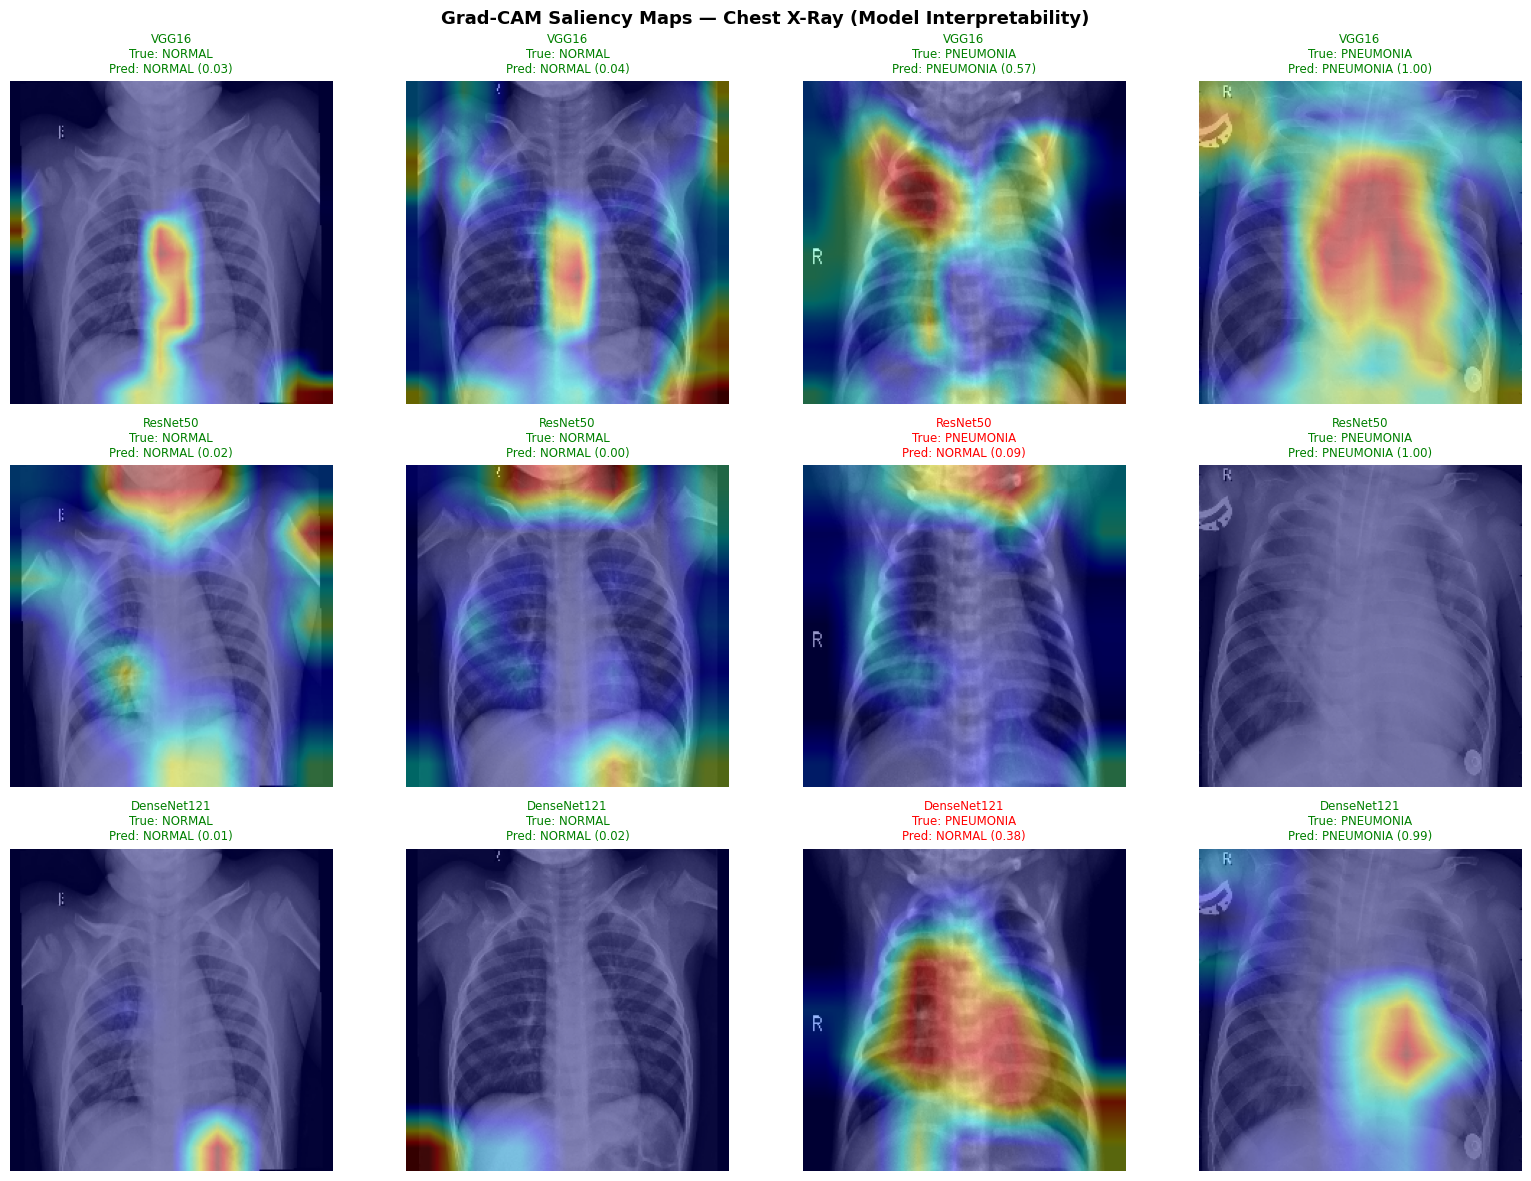

✅ Grad-CAM maps saved


In [17]:
def get_last_conv(model_name):
    return {'VGG16': 'block5_conv3',
            'ResNet50': 'conv5_block3_out',
            'DenseNet121': 'conv5_block16_concat'}[model_name]

def gradcam(model, img_array, last_conv_layer):
    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        class_channel   = preds[:, 0]
    grads   = tape.gradient(class_channel, conv_out)
    pooled  = tf.reduce_mean(grads, axis=(0,1,2))
    heatmap = conv_out[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay(img, heatmap, alpha=0.4):
    hm = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    hm = cv2.applyColorMap(np.uint8(255*hm), cv2.COLORMAP_JET)
    hm = cv2.cvtColor(hm, cv2.COLOR_BGR2RGB)
    return np.uint8(img*255*(1-alpha) + hm*alpha)

# Grab 4 test images (2 normal, 2 pneumonia)
import pathlib
normal_imgs    = list(pathlib.Path(f'{TEST_DIR}/NORMAL').glob('*.jpeg'))[:2]
pneum_imgs     = list(pathlib.Path(f'{TEST_DIR}/PNEUMONIA').glob('*.jpeg'))[:2]
sample_paths   = normal_imgs + pneum_imgs
sample_labels  = ['NORMAL', 'NORMAL', 'PNEUMONIA', 'PNEUMONIA']

from tensorflow.keras.preprocessing.image import load_img, img_to_array

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Grad-CAM Saliency Maps — Chest X-Ray (Model Interpretability)',
             fontsize=13, fontweight='bold')

for row, (name, model) in enumerate(models_trained.items()):
    try:
        last_conv = get_last_conv(name)
        for col, (path, true_label) in enumerate(zip(sample_paths, sample_labels)):
            img     = load_img(path, target_size=IMG_SIZE)
            arr     = img_to_array(img) / 255.0
            inp     = np.expand_dims(arr, 0)
            hm      = gradcam(model, inp, last_conv)
            result  = overlay(arr, hm)
            pred_p  = float(model.predict(inp, verbose=0)[0][0])
            pred_l  = 'PNEUMONIA' if pred_p >= 0.5 else 'NORMAL'
            correct = pred_l == true_label
            axes[row, col].imshow(result)
            axes[row, col].set_title(
                f'{name}\nTrue: {true_label}\nPred: {pred_l} ({pred_p:.2f})',
                fontsize=8.5, color='green' if correct else 'red'
            )
            axes[row, col].axis('off')
    except Exception as e:
        print(f'Grad-CAM error for {name}: {e}')

plt.tight_layout()
plt.savefig('gradcam_xray.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grad-CAM maps saved')

## ✅ Step 18 — Download All Results

In [18]:
from google.colab import files

# Save JSON summary
summary = {
    name: {
        'accuracy'  : round(float(r['accuracy']), 4),
        'precision' : round(float(r['precision']), 4),
        'recall'    : round(float(r['recall']), 4),
        'f1_score'  : round(float(r['f1']), 4),
        'auc_roc'   : round(float(r['auc']), 4),
        'train_time_hrs': r['train_time']
    }
    for name, r in results.items()
}
with open('xray_results_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Final Results:')
print(json.dumps(summary, indent=2))

# Zip all outputs
output_files = [
    'sample_xrays.png', 'class_distribution.png',
    'training_curves_xray.png', 'confusion_matrices_xray.png',
    'roc_curves_xray.png', 'model_comparison_xray.png',
    'gradcam_xray.png', 'xray_results_summary.json'
]
with zipfile.ZipFile('xray_dissertation_results.zip', 'w') as zf:
    for f_name in output_files:
        if os.path.exists(f_name):
            zf.write(f_name)
            print(f'  Added: {f_name}')

files.download('xray_dissertation_results.zip')
print('\n✅ All results downloaded — use in Chapter 4!')

Final Results:
{
  "VGG16": {
    "accuracy": 0.9006,
    "precision": 0.9432,
    "recall": 0.8949,
    "f1_score": 0.9184,
    "auc_roc": 0.965,
    "train_time_hrs": 0.94
  },
  "ResNet50": {
    "accuracy": 0.8686,
    "precision": 0.9326,
    "recall": 0.8513,
    "f1_score": 0.8901,
    "auc_roc": 0.9412,
    "train_time_hrs": 1.07
  },
  "DenseNet121": {
    "accuracy": 0.8942,
    "precision": 0.9475,
    "recall": 0.8795,
    "f1_score": 0.9122,
    "auc_roc": 0.9659,
    "train_time_hrs": 0.77
  }
}
  Added: sample_xrays.png
  Added: class_distribution.png
  Added: training_curves_xray.png
  Added: confusion_matrices_xray.png
  Added: roc_curves_xray.png
  Added: model_comparison_xray.png
  Added: gradcam_xray.png
  Added: xray_results_summary.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All results downloaded — use in Chapter 4!
